**Bevezetés a SymPy használatába**

A **SymPy** egy Python-alapú, nyílt forráskódú könyvtár szimbolikus matematikai számításokhoz. Lehetővé teszi, hogy algebrai kifejezésekkel ne csupán numerikus értékekkel dolgozzunk, hanem ténylegesen a matematikai formulák szintjén manipuláljuk azokat.

A SymPy használatával analitikusan végezhetünk műveleteket, például:
- deriválás, integrálás,
- egyenletrendezés,
- sorfejtés,
- mátrixműveletek szimbolikus elemekkel,
- algebrai egyszerűsítés vagy bonyolítás.

Ez különösen hasznos:
- matematikai modellek elemzésekor,
- elméleti összefüggések levezetésében,
- mérnöki vagy fizikai problémák jelképes (szimbolikus) megoldásakor,
- ha szeretnénk pontos, nem numerikus eredményeket kapni.

A SymPy jól használható oktatási célra is, mivel a kimenetei könnyen olvashatóak, és a matematikai logikát követhetően jelenítik meg.

In [1]:
# A SymPy könyvtár importálása
import sympy as sp

In [2]:
# Egy vagy több szimbolikus változó definiálása
x = sp.Symbol('x')          # Egyetlen változó
a, b, c, y, z = sp.symbols('a b c y z')  # Több változó egyszerre

# Ellenőrzésképp kiíratjuk az egyik szimbolikus változót
print(x)

x


> **Megjegyzés:** A Python alapból nem támogatja a matematikai szimbólumként viselkedő változók önálló kiíratását.
> Például, ha csak annyit írnánk, hogy `print(k)` egy előzetesen nem definiált `k` változóra, akkor hibát kapnánk.
> A SymPy ezért bevezet szimbolikus változókat, amelyeket először deklarálni kell a `sp.Symbol()` vagy `sp.symbols()` függvényekkel.

In [3]:
print(k)

NameError: name 'k' is not defined

In [4]:
# Műveletek a szimbólumokkal
x**2

x**2

In [5]:
a * x**2 + b * x + c

a*x**2 + b*x + c

A SymPy saját szimbolikus verziókat kínál a matematikai függvényekből, ezért a szokásos `math.sin` vagy `numpy.sin` helyett a `sympy.sin` (vagyis `sp.sin`) függvényt kell használni, ha szimbolikus műveleteket szeretnél végezni. Igaz ez a többi függvényre is.

In [6]:
sp.sin(x**4) - sp.exp(c)

-exp(c) + sin(x**4)

**Elérhető SymPy függvények listázása** (gyors módszer)

A Jupyter Notebook nagyon kényelmes módot biztosít arra, hogy gyorsan megnézzük, milyen függvények és változók érhetők el egy adott modulban.

Ha beírjuk, hogy sp. majd közvetlenül utána megnyomjuk a TAB billentyűt, akkor automatikusan megjelenik egy legördülő menü, amelyből választhatóak az elérhető függvények és változók.

Ezzel a módszerrel gyorsan áttekinthető a SymPy által kínált lehetőségek.

In [7]:
sp.cos(x)

cos(x)

Ha a Jupyter cella utolsó sorában egy SymPy-kifejezést adunk meg akkor a Jupyter automatikusan felismeri, hogy ez egy SymPy-objektum, és LaTeX-stílusban jeleníti meg, nem pedig szövegként.
A print() függvény viszont csak sima szöveget ír ki a konzolra (plain text), nem LaTeX-formátumban.

In [8]:
# Példa kifejezés létrehozására
z = x**2 + a*x + b*x + a*b
print(z)

a*b + a*x + b*x + x**2


Használható a `display()` függvény, amely a Jupyter IPython.display modulján keresztül automatikusan LaTeX-formázással jeleníti meg a SymPy-kifejezéseket.

In [9]:
from sympy import symbols
from sympy import init_printing
from IPython.display import display

# Szép megjelenítés engedélyezése
init_printing()

# Megjelenítés
display(z)

Ha egy kifejezést hozunk létre, például `z = a * x**2 + b * x + c`, akkor az `expr` nem új szimbolikus változó lesz, hanem egy szimbolikus **kifejezés** (`sympy.Expr` típusú objektum), amely a meglévő szimbolikus változókat tartalmazza.
Az ilyen kifejezéseken szabadon végezhetünk szimbolikus műveleteket (pl. deriválás, behelyettesítés, egyszerűsítés).

In [10]:
# Művelet végzése az új változóval:
z**2

In [11]:
# A `factor()` függvény egy szimbolikus kifejezést tényezőkre bont.
z.factor()

In [12]:
# Így is megadható:
sp.factor(z)

In [13]:
# Az `expand()` függvény a SymPy-ben a kifejezések kibontását végzi el
q = sp.expand(z**2)
display(q)

In [14]:
sp.factor(q)

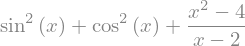

In [16]:
# egy bonyolultabb kifejezés definiálása
expr = (sp.sin(x)**2 + sp.cos(x)**2) + (x**2 - 4)/(x - 2)
display(expr)

# a kifejezés egyszerűsítése
sp.simplify(expr)

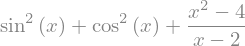

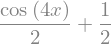

In [17]:
# Trigonometrikus kifejezés definiálása
exprtr = sp.sin(x)**4 - 2*sp.cos(x)**2*sp.sin(x)**2 + sp.cos(x)**4
display(expr)

# Kifejezés trigonometrikus egyszerűsítése
sp.trigsimp(exprtr)

# Lehetséges, hogy vannak esetek, amikor ez működik jól a simplify() helyett.
# jegyezzük meg.

In [18]:
# cos(2x) kibontása nem sikerül:
sp.expand(sp.cos(2*x))

In [19]:
# sp.expand_trig() paranccsal igen:
sp.expand_trig(sp.cos(2*x))

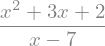

Számláló:


Nevező:


In [20]:
# Egy tört kifejezés létrehozása
expr = (x**2 + 3*x + 2)/(x - 7)
display(expr)

# Számláló lekérése
num = sp.numer(expr)

# Nevező lekérése
denom = sp.denom(expr)

# Eredmények kiírása
print("Számláló:")
display(num)
print("Nevező:")
display(denom)

Eredeti kifejezés:


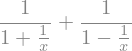

simplify eredménye:


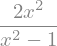

ratsimp eredménye:


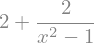

In [21]:
# vannak esetek amikor érdemes a ratsimp() függvénnyel is próbálkozni
expr = (1/(1 + 1/x)) + (1/(1 - 1/x))

# simplify próbálkozás
simplified = sp.simplify(expr)

# ratsimp próbálkozás
ratsimplified = sp.ratsimp(expr)

print("Eredeti kifejezés:")
display(expr)

print("simplify eredménye:")
display(simplified)

print("ratsimp eredménye:")
display(ratsimplified)

In [22]:
# Egy példa polinom létrehozása
expr = 4*x**3 - 2*x**2 + 7*x - 5
display(expr)

# x**3 tag együtthatójának lekérése
expr.coeff(x, 3)

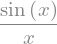

In [23]:
# Határérték számítása
expr = sp.sin(x) / x
display(expr)

# Határérték x → 0
sp.limit(expr, x, 0)

A `Limit()` egy szimbolikus objektum, ami nem számolja ki a határértéket, csak leírja azt formálisan. Ez azért fontos, mert Jupyter Notebookban sokszor nem csak az eredményt (pl. 1) szeretnénk látni, hanem az egész határérték-kifejezést szépen megformázva, mintha egy jegyzetben vagy könyvben lenne.

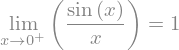

In [24]:
from sympy import Limit
# formális határérték
lim_expr = Limit(expr, x, 0)

# kiszámított határérték
lim_value = lim_expr.doit()
#  doit() arra való, hogy kiértékelje egy összetett szimbolikus művelet eredményét

# szépen megjelenítve, egyenletként
display(sp.Eq(lim_expr, lim_value))

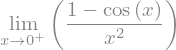

In [25]:
# Kifejezés kiírva
Limit((1 - sp.cos(x)) / x**2, x, 0)

In [26]:
# Kiértékelve:
(Limit((1 - sp.cos(x)) / x**2, x, 0)).doit()

Taylor-sor x=0 körül 5. fokig:


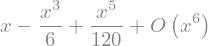

Maradék nélküli forma:


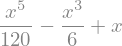

In [27]:
# Taylor-sor alkalmazása
# Függvény definiálása
f = sp.sin(x)

# Taylor-sor kiszámítása x=0 körül, 6. fokig (ez 5-ödik rendű közelítés)
# A sor x=0 körüli kifejtése (ez a Maclaurin-sor is egyben)
taylor = f.series(x, 0, 6)   # 6: a sorban az x^5-ig megy

# Kimenet tartalmazhat O(x^6) jelölést, ami a maradék tagot jelenti
print("Taylor-sor x=0 körül 5. fokig:")
display(taylor)

# Ha szeretnéd, a maradék tagot (Order term) el is hagyhatod:
taylor_simplified = taylor.removeO()
print("Maradék nélküli forma:")
display(taylor_simplified)

In [28]:
# Behelyettesítés

# a=100 behelyettesítése
expr_sub1 = z.subs(a, 100)

# x=2, a=3 és b=8 egyszerre
expr_sub2 = z.subs({x: 2, a: 3, b: 8})

# Eredmények kiírása
print("Eredeti kifejezés:")
display(z)

print("Behelyettesítés után (a=100):")
display(expr_sub1)

print("Behelyettesítés után (x=2, a=3, b=8):")
display(expr_sub2)

Eredeti kifejezés:


Behelyettesítés után (a=100):


Behelyettesítés után (x=2, a=3, b=8):


In [29]:
# Derivált x szerint
f = x**3 + 2*x**2 + x
df_dx = sp.diff(f, x)

# Második derivált x szerint
d2f_dx2 = sp.diff(f, x, 2)

print("f(x):")
display(f)
print("\nf'(x):")
display(df_dx)
print("\nf''(x):")
display(d2f_dx2)
display(sp.expand(d2f_dx2))

f(x):



f'(x):



f''(x):


In [30]:
# Kétváltozós kifejezés
g = x**2 * y + sp.sin(x*y)

# Parciális derivált x szerint
dg_dx = sp.diff(g, x)

# Parciális derivált y szerint
dg_dy = sp.diff(g, y)

print("g(x, y):")
display(g)
print("\n∂g/∂x:")
display(dg_dx)
print("\n∂g/∂y:")
display(dg_dy)

g(x, y):



∂g/∂x:



∂g/∂y:


In [28]:
# láncszabály alkalmazására példa
f = sp.sin(x**2)

# Deriválás x szerint (láncszabály automatikusan működik)
df_dx = sp.diff(f, x)

# Eredmény kiírása
print("f(x):")
display(f)
print("\nf'(x):")
display(df_dx)

f(x):



f'(x):


f(x):


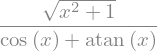


f'(x):


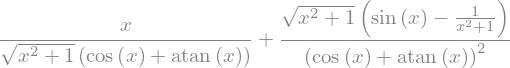

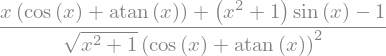

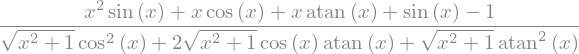

In [29]:
# Bonyolult kifejezés: tartalmaz gyököt, törtet, cos-t és arctan-t
f = sp.sqrt(x**2 + 1) / (sp.cos(x) + sp.atan(x))

# Deriválás x szerint
df_dx = sp.diff(f, x)

# Eredmény kiírása
print("f(x):")
display(f)
print("\nf'(x):")
display(df_dx)
display(sp.simplify(df_dx))
display(sp.ratsimp(df_dx))

In [30]:
# Határozatlan integrál kiszámítása
# Az integrálandó függvény
f = x**2

# A szintaxis: integrate(kifejezés, változó)
fint = sp.integrate(f, x)

# Eredmény kiírása
print("A határozatlan integrál:")
display(fint)

A határozatlan integrál:


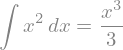

In [31]:
# Határozatlan integrál objektum létrehozása
I = sp.Integral(f, x)

# Kiértékelés és kiírás
Ires = I.doit()
display(sp.Eq(I, Ires))

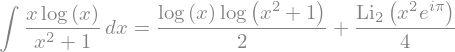

In [32]:
# Bonyolultabb függvény kiszámítása időigényesebb:
f = x * sp.log(x) / (1 + x**2)
I = sp.Integral(f, x)

# Kiértékelés és kiírás
Ires = I.doit()
display(sp.Eq(I, Ires))

A megoldásban kapott Li₂(x) a dilogaritmus függvény: 

In [33]:
help(sp.polylog)

Help on class polylog in module sympy.functions.special.zeta_functions:

class polylog(sympy.core.function.DefinedFunction)
 |  polylog(s, z)
 |
 |  Polylogarithm function.
 |
 |  Explanation
 |  ===========
 |
 |  For $|z| < 1$ and $s \in \mathbb{C}$, the polylogarithm is
 |  defined by
 |
 |  .. math:: \operatorname{Li}_s(z) = \sum_{n=1}^\infty \frac{z^n}{n^s},
 |
 |  where the standard branch of the argument is used for $n$. It admits
 |  an analytic continuation which is branched at $z=1$ (notably not on the
 |  sheet of initial definition), $z=0$ and $z=\infty$.
 |
 |  The name polylogarithm comes from the fact that for $s=1$, the
 |  polylogarithm is related to the ordinary logarithm (see examples), and that
 |
 |  .. math:: \operatorname{Li}_{s+1}(z) =
 |                  \int_0^z \frac{\operatorname{Li}_s(t)}{t} \mathrm{d}t.
 |
 |  The polylogarithm is a special case of the Lerch transcendent:
 |
 |  .. math:: \operatorname{Li}_{s}(z) = z \Phi(z, s, 1).
 |
 |  Examples
 |  ====

In [34]:
# Határozott integrál kiszámítása 0 és 2 között
f = x**2
integral = sp.integrate(f, (x, 0, 2))

# Eredmény kiírása
print("∫₀² x² dx =")
display(integral)

∫₀² x² dx =


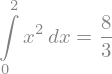

In [35]:
# Másképpen kiértékelve:
I = sp.Integral(f, (x,0,2))

# Kiértékelés és kiírás
Ires = I.doit()
display(sp.Eq(I, Ires))

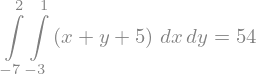

In [36]:
# Kettős integrál
f = x + y + 5
I = sp.Integral(f, (x, -3, 1), (y, -7, 2))

# Kiértékelés és kiírás
Ires = I.doit()
display(sp.Eq(I, Ires))

v1 =



v2 =



Skaláris szorzat (v1 ⋅ v2):



Vektoriális szorzat (v1 × v2):


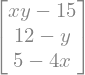

In [37]:
# Vektor komponensek (szimbolikus vagy konkrét számok is lehetnek)
v1 = sp.Matrix([1, x, 3])
v2 = sp.Matrix([4, 5, y])

# Skaláris (dot) szorzat
dot_product = v1.dot(v2)

# Vektoriális (cross) szorzat – csak 3D vektoroknál értelmezett
cross_product = v1.cross(v2)

# Eredmények kiírása
print("v1 =")
display(v1)
print()
print("v2 =")
display(v2)
print()
print("Skaláris szorzat (v1 ⋅ v2):")
display(dot_product)
print()
print("Vektoriális szorzat (v1 × v2):")
display(cross_product)

Hossz (norma):


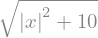


Normalizált vektor:


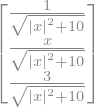

In [38]:
# Vektor hossza (norma)
length = v1.norm()

# Normalizált vektor
v1_normalized = v1 / length

# Eredmények kiírása
print("Hossz (norma):")
display(length)
print()
print("Normalizált vektor:")
display(v1_normalized)

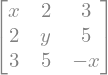

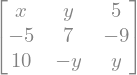

In [39]:
# A mátrix szimbolikusan
A = sp.Matrix([
    [x, 2, 3],
    [2, y, 5],
    [3, 5, -x]
])

# B mátrix szimbolikusan
B = sp.Matrix([
    [x, y, 5],
    [-5, 7, -9],
    [10, -y, y]
])
display(A)
display(B)

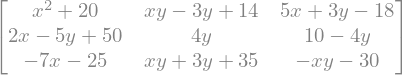

In [40]:
# Mátrixok összeszorzása
display(A*B)
# !!! FONTOS !!!
# SymPy-ban a * NEM elemenkénti szorzást jelent mint NumPy esetén!

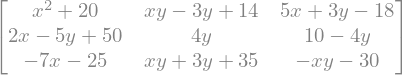

In [41]:
# @ is működik
display(A @ B)

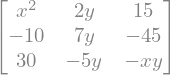

In [42]:
# Elemenkénti szorzás
display(A.multiply_elementwise(B))

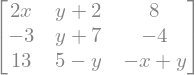

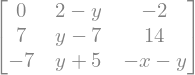

In [43]:
# Műveletek az elemekkel
display(A+B)
print() # üres sor
display(A-B)

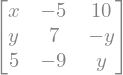

In [44]:
# Transzponált
display(B.T)

In [45]:
# Trace
A.trace()

In [46]:
# Det
display(A.det())
display(B.det())

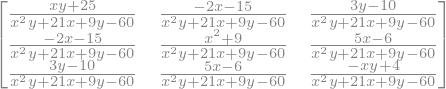

In [47]:
# Inverz
A.inv()

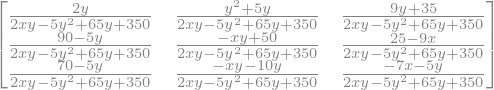

In [48]:
# Inverz
B.inv()

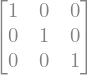

In [49]:
# 3x3-as egységmátrix
sp.eye(3)

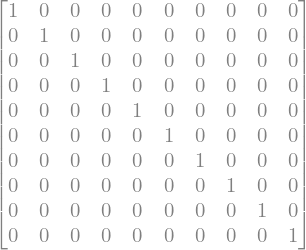

In [50]:
# 10x10-es egységmátrix
sp.eye(10)

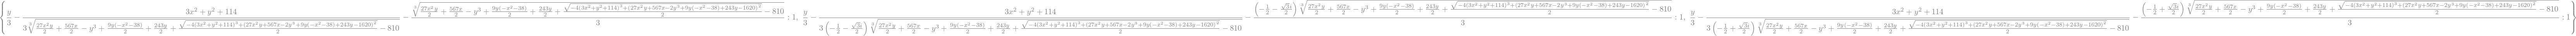

In [51]:
# Sajátértékek és multipicitásuk:
A.eigenvals()

C =


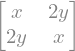

sajátértékek és multipicitásuk:


In [52]:
# Sajátértékek és multipicitásuk egyszerűbb mintapéldával:
C = sp.Matrix([
    [x, 2*y],
    [2*y, x]
])
print("C =")
display(C)
print("sajátértékek és multipicitásuk:")
C.eigenvals()

In [53]:
# Sajátértékek és sajátvektorok az A mátrix esetén
eigen_data = A.eigenvects()

# Ez egy listát ad vissza, amelynek elemei: (sajátérték, multiplicitás, [sajátvektor(ok)])

# Kiírás (bonyulult ennél a példánál)
for val, mult, vects in eigen_data:
    print(f"Sajátérték: {val} (multiplicitás: {mult})")
    for v in vects:
        print("  Sajátvektor:", v)

Sajátérték: y/3 - (3*x**2 + y**2 + 114)/(3*(27*x**2*y/2 + 567*x/2 - y**3 + 9*y*(-x**2 - 38)/2 + 243*y/2 + sqrt(-4*(3*x**2 + y**2 + 114)**3 + (27*x**2*y + 567*x - 2*y**3 + 9*y*(-x**2 - 38) + 243*y - 1620)**2)/2 - 810)**(1/3)) - (27*x**2*y/2 + 567*x/2 - y**3 + 9*y*(-x**2 - 38)/2 + 243*y/2 + sqrt(-4*(3*x**2 + y**2 + 114)**3 + (27*x**2*y + 567*x - 2*y**3 + 9*y*(-x**2 - 38) + 243*y - 1620)**2)/2 - 810)**(1/3)/3 (multiplicitás: 1)
  Sajátvektor: Matrix([[(5*x - 5*y - 6)*(y/3 - (3*x**2 + y**2 + 114)/(3*(27*x**2*y/2 + 567*x/2 - y**3 + 9*y*(-x**2 - 38)/2 + 243*y/2 + sqrt(-4*(3*x**2 + y**2 + 114)**3 + (27*x**2*y + 567*x - 2*y**3 + 9*y*(-x**2 - 38) + 243*y - 1620)**2)/2 - 810)**(1/3)) - (27*x**2*y/2 + 567*x/2 - y**3 + 9*y*(-x**2 - 38)/2 + 243*y/2 + sqrt(-4*(3*x**2 + y**2 + 114)**3 + (27*x**2*y + 567*x - 2*y**3 + 9*y*(-x**2 - 38) + 243*y - 1620)**2)/2 - 810)**(1/3)/3)/(15*x - 15*y + 32) + 5*(y/3 - (3*x**2 + y**2 + 114)/(3*(27*x**2*y/2 + 567*x/2 - y**3 + 9*y*(-x**2 - 38)/2 + 243*y/2 + sqrt(-4*(3*x*

Sajátérték:


Multiplicitás:


Sajátvektor:


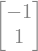

Sajátérték:


Multiplicitás:


Sajátvektor:


In [54]:
# Sajátértékek és sajátvektorok a C mátrix esetén
eigen_data = C.eigenvects()

# Kiírás
for val, mult, vects in eigen_data:
    print("Sajátérték:")
    display(val)
    print("Multiplicitás:")
    display(mult)
    for v in vects:
        print("Sajátvektor:")
        display(v)

In [55]:
# Egyenlet megadása:
eq = sp.Eq(x**2 - 9, 0)

# sp.Eq() (teljes nevén sympy.Eq) egy szimbolikus egyenletobjektum,
# amely egy bal oldalt és egy jobb oldalt kapcsol össze egyenlőségként

# Megoldás kérdése
megoldas = sp.solve(eq, x)

print("egyenlet:")
display(eq)
print()
print("Megoldás(ok):")
display(megoldas)

egyenlet:



Megoldás(ok):


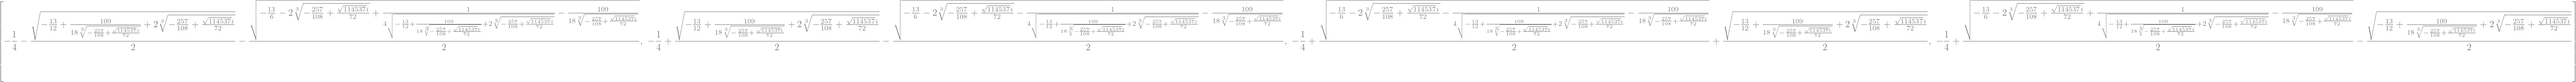

In [56]:
# Negyedfokú egyenlet
display(sp.solve(sp.Eq(x**4 + x**3 + 2*x**2 + x + 9, 0), x))

In [57]:
# Az sp.solve() nem csak polinomokra jó — a SymPy egy általános szimbolikus egyenletmegoldó, így sokféle típusú egyenletet tud kezelni.
egyenlet = sp.Eq(sp.exp(x), 5)
display(egyenlet)
print("megoldás(ok) x-re:")
sp.solve(egyenlet, x)

megoldás(ok) x-re:


In [58]:
egyenlet = sp.Eq(sp.log(x), 2)
display(egyenlet)
print("megoldás(ok) x-re:")
sp.solve(egyenlet, x)

megoldás(ok) x-re:


In [59]:
egyenlet = sp.Eq(sp.sin(x), 1)
display(egyenlet)
print("megoldás(ok) x-re:")
sp.solve(egyenlet, x)

megoldás(ok) x-re:


megoldás(ok) x-re:


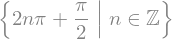

In [60]:
# Megjegyzés: sp.solve(sp.Eq(sp.sin(x), 1), x) csak egy „fő” megoldást ad (pl. pi/2),
# nem a teljes periodikus halmazt. Trigonometrikus egyenleteknél használhatjuk a solveset-et
# és megadhatjuk a tartományt:
#   sp.solveset(sp.sin(x) - 1, x, domain=sp.S.Reals)  # -> {2*pi*n + pi/2 | n ∈ ℤ}
display(egyenlet)
print("megoldás(ok) x-re:")
sp.solveset(sp.sin(x) - 1, x, domain=sp.S.Reals)

megoldás(ok) x-re a [0,10] tartományon:


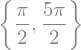

In [61]:
# Intervallumra például:
#   sp.solveset(sp.sin(x) - 1, x, domain=sp.Interval(0, 10))
display(egyenlet)
print("megoldás(ok) x-re a [0,10] tartományon:")
sp.solveset(sp.sin(x) - 1, x, domain=sp.Interval(0, 10))

In [62]:
# Speciális megoldás:
egyenlet = sp.Eq(sp.log(x), x)
display(egyenlet)
print("megoldás x-re:")
sp.solve(egyenlet, x)
# A válaszban szereplő W egy speciális függvény, a Lambert W-függvény.

megoldás x-re:


In [63]:
# Ha zárt megoldás nincs, akkor a solve() lehet, hogy nem ad vissza semmit, vagy csak részleges választ ad.
egyenlet = sp.Eq(sp.log(x) + sp.sin(x), x)
display(egyenlet)
sp.solve(egyenlet, x)

NotImplementedError: multiple generators [x, log(x), sin(x)]
No algorithms are implemented to solve equation -x + (log(x) + sin(x))

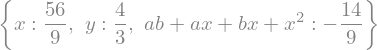

In [64]:
# Egyenletrendszer megoldása
eq1 = sp.Eq(x + z + y, 6)
eq2 = sp.Eq(2*x - z, 14)
eq3 = sp.Eq(-x + 2*y - z, -2)

# Megoldás
sp.solve([eq1, eq2, eq3], (x, y, z))

A `lambdify()` egy olyan függvényt hoz létre, amely
- bemenetként számértéket vár egy szimbolikus változó helyére,
- a szimbolikus kifejezést gyorsan kiértékeli,
- Python, NumPy, Math vagy más backendekkel működik.

Általános szintaxis:<br>
`from sympy import lambdify`<br>
`f = lambdify(változó(k), kifejezés, modul)`<br>
modul pl. "math" vagy "numpy"

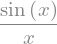

0.8414709848078965
0.9983341664682815


In [65]:
display(expr)
# Numerikus függvénnyé alakítás (math modullal)
f = sp.lambdify(x, expr, 'math')

# Kiértékelés
print(f(1))      # → sin(1)/1 ≈ 0.841...
print(f(0.1))    # → sin(0.1)/0.1 ≈ 0.998...

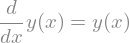

A differenciálegyenlet megoldása:


In [66]:
# Differenciálegyenlet megoldása analitikusan
# Szimbolikus változók
x = sp.Symbol('x')          # független változó
y = sp.Function('y')         # ismeretlen függvény dfiniálása

# Differenciálegyenlet felírása
de = sp.Eq(y(x).diff(x), y(x))    # dy/dx = y
display(de)

# Megoldás kérése
megoldas = sp.dsolve(de, y(x))    # megoldás y(x)-re

# Eredmény kiírása
print("A differenciálegyenlet megoldása:")
display(megoldas)

# sp.Function('y') létrehoz egy függvényjelölést.
# dsolve() próbál általános szimbolikus megoldást adni.

In [67]:
# Kezdeti feltétel: y(0) = 2
megoldas_ivp = sp.dsolve(de, y(x), ics={y(0): 2})

display(megoldas_ivp)

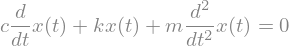

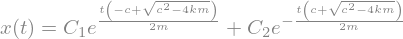

In [68]:
# Példa:
# Idő mint független real változó
t = sp.Symbol('t', real=True)

# Paraméterek: tömeg, csillapítás, rugóállandó
m, c, k = sp.symbols('m c k', real=True, positive=True)

# Ismeretlen függvény: x(t)
x = sp.Function('x')

# Másodrendű differenciálegyenlet: m*x'' + c*x' + k*x = 0
de = sp.Eq(m * x(t).diff(t, 2) + c * x(t).diff(t) + k * x(t), 0)
display(de)

# Megoldás szimbolikusan
megoldas = sp.dsolve(de, x(t))

# Kiírás
display(megoldas)

C:\Users\barnabaspiri\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
C:\Users\barnabaspiri\AppData\Local\Programs\Python\Python313\Lib\site-packages\matplotlib\cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


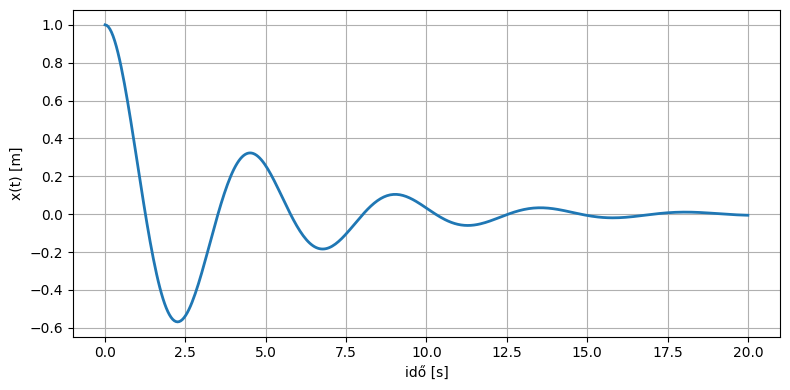

In [69]:
# Megoldás kezdeti feltételekkel
import numpy as np
import matplotlib.pyplot as plt

# Kezdőfeltételek: x(0) = 1, x'(0) = 0
ics = {x(0): 1, x(t).diff(t).subs(t, 0): 0}

# DE megoldása
sol = sp.dsolve(de, x(t), ics=ics)

# Paraméterek beillesztése (numerikus értékek)
sol_subs = sol.rhs.subs({m: 1.0, c: 0.5, k: 2.0})
# A sol egyenletet tartalmaz: pl. x(t) = ...  (Eq objektum)
# A sol.rhs a megoldás jobb oldala, azaz maga a kifejezés: x(t) = sol.rhs
# A subs({m:..., c:..., k:...}) a szimbolikus paramétereket (m, c, k) konkrét értékekre cseréli
# Így a megoldás numerikusan kiértékelhetővé válik pl. plottolásra

# Lambdify: numerikus függvény készítése
x_t_func = sp.lambdify(t, sol_subs, modules='numpy')

# Időtengely létrehozása és numerikus kiértékelés
T = np.linspace(0, 20, 400)
X = x_t_func(T)

# Ábrázolás
plt.figure(figsize=(8, 4))
plt.plot(T, X, label='x(t)', linewidth=2)
plt.xlabel('idő [s]')
plt.ylabel('x(t) [m]')
plt.grid(True)
plt.tight_layout()
plt.show()

Gradiens, Divergencia, Rótáció számítása adott koordináta-rendszerben programcsomag segítségével:

In [70]:
import sympy as sp
from sympy.vector import CoordSys3D, gradient, divergence, curl
# Ez a sor importálja a vektoranalízishez szükséges eszközöket:
# - CoordSys3D: 3D koordinátarendszer létrehozása (x, y, z, i, j, k)
# - gradient: gradiens számítás 
# - divergence: divergencia számítás 
# - curl: rotáció (örvénylés) számítás 
from sympy.vector import CoordSys3D, gradient, divergence, curl

# Ez a parancs létrehoz egy 3D derékszögű koordinátarendszert 'N' néven.
# Az N objektum automatikusan tartalmazza:
# - koordinátákat: N.x, N.y, N.z
# - bázisvektorokat: N.i, N.j, N.k
N = CoordSys3D('N')

# Változók (x, y, z) a rendszerből
x, y, z = N.x, N.y, N.z

In [71]:
# Skalárfüggvény gradiense
phi = 5*x**2 + y**3 - z**4
grad_phi = gradient(phi)

print("Skalárfüggvény:")
display(phi)
print("\nGradiens (egy skalármezőre):")
display(grad_phi)

Skalárfüggvény:



Gradiens (egy skalármezőre):


In [72]:
# Példa vektormező definiálása: F = [x²y, sin(yz), exp(z) + xy]
F = x**2 * y * N.i + sp.sin(y * z) * N.j + (sp.exp(z) + x * y) * N.k

# Divergencia számítása
div_F = divergence(F)

# Eredmények kiírása
print("Divergencia:")
display(div_F)

Divergencia:


In [73]:
# Rotáció számítása (curl)
rot_F = curl(F)

print("\nRotáció (curl):")
display(rot_F)


Rotáció (curl):



Gradiens:


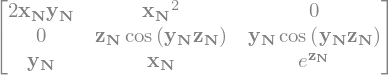

In [74]:
# Gradiens (MÁS FÜGGVÉNY MINT SKALÁRNÁL)
# A sympy.vector modul nem támogatja közvetlenül a vektormező gradiensének számítását.
# Ehhez a vektor komponenseit skalárként kell kigyűjteni, majd jacobian()-nal kézzel kiszámolni.
# Ilyen műveletre nincs egysoros beépített függvény mint a curl() vagy divergence() esetén.
# A vektormező komponenseinek kigyűjtése skalár alakban
F_components = sp.Matrix([
    F.dot(N.i),
    F.dot(N.j),
    F.dot(N.k)
])

# Gradiens
grad_F = F_components.jacobian([x, y, z])

print("\nGradiens:")
display(grad_F)